# Quickstart

A star-forming galaxy with 12 broadband fluxes from GALEX, SDSS, 2MASS,
and WISE (UV through near-IR), fitted with NUTS on a differentiable JAX
forward model.

Deliberately minimal — the point is to show how *fast* the JIT-compiled
forward model and gradients are. Double power-law SFH with ongoing star
formation, single-component Calzetti dust attenuation, baked-in nebular emission,
free stellar metallicity, redshift fixed at 0.05. Four free SFH parameters
(alpha, beta, tau, log_total_mass) plus dust V-band optical depth, metallicity;
seven free parameters total. See `04_building_models.py` for the recipe grammar
and `02_sed_anatomy.py` for a panchromatic model with dust IR re-emission,
nebular, AGN, and IGM enabled.

In [1]:
# Shared notebook setup (see notebooks/_setup.py): quiets the framework notices
# that do not change the science, and loads the SSP grid.
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Re-enable BakedInNebularWarning for this notebook: the baked-in SSP is the
# notebook's headline modeling assumption and the warning signals the frozen
# logU/logZ_gas assumptions to users.
import warnings
warnings.filterwarnings("default", message=".*BakedInBackend.*")

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Data,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    citations,
    cosmology,
    generate_mock,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

An FSPS-generated SSP grid with nebular emission baked in at log(U) = −3.0
and solar gas-phase metallicity (Z_gas/Zsun = 1.0). Stellar metallicity is
free to vary; gas-phase metallicity is fixed by the grid. Per the project
contract, these are independent knobs, so the nebular contribution does not
respond to fitted stellar Z. `BakedInNebularWarning` on fit start marks this
assumption.

In [2]:
SSP_NAME = "prsc_miles_chabrier_wNE"
ssp = tengri.load_ssp(SSP_NAME, download=True)

FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
]
obs = Observation(photometry=Photometry.from_names(FILTERS))

src/tengri/components/stellar/sps/dsps_wrapper.py:354: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


## Build the model

Double power-law SFH with single-component Calzetti dust attenuation
(V-band optical depth τ_V free), baked-in nebular emission, and free stellar
metallicity; redshift fixed at z = 0.05: seven free parameters. The DPL has
five shape parameters (alpha, beta, tau_gyr, age_gyr, log_total_mass), giving
the SFR flexibility to peak and then decline while remaining star-forming at the
present epoch. Kept minimal on purpose. Dust IR re-emission, full photoionized
nebular grids, and AGN are covered in `02_sed_anatomy.py`.

A single Calzetti screen reddens the entire stellar population uniformly.
Its simplicity makes it suitable for a quickstart example — the model
prioritizes interpretability and speed over the realism of a stratified
ISM.

In [3]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh={"type": "dpl", "all_params": FREE},
    dust_attenuation={
        "type": "single_component",
        "law": "calzetti",
        "tau_v": Uniform(0.0, 4.0),
    },
    neb={"type": "ssp"},
    met={"logzsol": Uniform(-2.0, 0.2)},
    redshift=Fixed(0.05),
)

# The model that gets fitted. `ForwardModel` pairs the SED with the instrument
# that observed it; the observation is inherited from the SED, so there is
# nothing to re-declare here.
forward = ForwardModel.build(sed=sed_model)

print(sed_model.summary())
citations.print_citations(sed_model)

src/tengri/forward/sed_model.py:2871: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress when building via SEDModel.build: warnings.filterwarnings('ignore', message='BakedInBackend: nebular emission is baked'). (ionizing_source_warning='suppress' also works, but it is a BakedInBackend(...) constructor argument and the build grammar does not forward it.)
  self._nebular_backend = BakedInBackend()


Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     12 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Fast path:   photometry LUT
  Components:  nebular=ssp

  Pipeline (3 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=baked_in]
    3. dust_attenuation [law=calzetti]

  Parameters:  7 free
──────────────────────────────────────────────────────────────────
Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
   

## Mock observation

One draw from the prior is the truth. `generate_mock` returns the
noiseless model fluxes, Gaussian uncertainties at the requested S/N,
and a noisy realization. The drawn truth is star-forming: we verify both that
the specific star formation rate (sSFR > 10⁻¹¹ /yr) and that the instantaneous
SFR at lookback time ≈ 0 (the present epoch) is positive — ensuring no
regressions to the SFH prior.

In [4]:
key = jax.random.PRNGKey(9)
key_truth, key_mock, key_fit = jax.random.split(key, 3)

truth = sed_model.spec.sample(key_truth)

# Verify truth is star-forming: both sSFR and current SFR > 0
truth_full_temp = {**sed_model.spec.get_fixed_values(), **truth}
pred_truth = sed_model.predict(truth_full_temp)
ssfr_truth = float(pred_truth.ssfr)
assert ssfr_truth > 1e-11, f"Truth is not star-forming: sSFR = {ssfr_truth:.3e} /yr (need > 1e-11 /yr)"

# Also verify current SFR (at lookback ~0) is positive
state_truth = sed_model.predict_state(truth_full_temp)
sfr_grid = np.asarray(state_truth.derived["sfr_history"])
t_lbt_grid = np.asarray(state_truth.derived["sfh_grid_lbt_yr"])
# Current SFR is at the youngest time (smallest lookback time)
sfr_current = sfr_grid[np.argmin(np.abs(t_lbt_grid))]
assert sfr_current > 0.0, f"SFR at present is not positive: {sfr_current:.3e} Msun/yr"

mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = effective_wavelengths_um(phot)

## One-time JIT compile

Cold compile is a few seconds; warm cache is milliseconds. The difference
between first and second call below shows the cost of compilation alone.

In [5]:
import time

p0 = {**sed_model.spec.get_fixed_values(), **truth}
predict_phot = jax.jit(sed_model.predict_photometry)
grad_fn = jax.jit(
    jax.grad(lambda p: 0.5 * jnp.sum(((sed_model.predict_photometry(p) - flux_obs) / noise) ** 2))
)

t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   warm:       {time.perf_counter() - t:8.4f} s")

t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  warm:       {time.perf_counter() - t:8.4f} s")

  forward kernel   first call:   0.0568 s  (compile + run)
  forward kernel   warm:         0.0004 s


  ∇log-likelihood  first call:   0.3100 s  (compile + run)
  ∇log-likelihood  warm:         0.0006 s


## Fit

`forward.fit(Data(photometry=(flux, noise)), ...)` is the whole interface: wrap
the data in the `Data` container with the channel name (here, `photometry`), hand
it to the fitter, and pick a method. The channel is explicit and unambiguous.

Multi-start ADAM for the MAP point estimate, then NUTS with four parallel
chains via `jax.vmap` for the full posterior. The `n_restarts=8` parameter runs
eight random inits in parallel and keeps the lowest-loss one, then NUTS is seeded
from that MAP point (`init_from=map_result`).

With `init_from=map_result`, the chains start at a good point, so warm-up can
be much shorter than a cold start. Here, 1000 warm-up steps are sufficient
with the DPL SFH model (which has extra shape freedom), achieving 0 divergences
and split-R̂ ≈ 1.0. The practical principle: cold chains need long burn-in;
MAP-initialized chains are fast from the start.

In [6]:
t = time.perf_counter()
map_result = forward.fit(
    Data(photometry=(flux_obs, noise)),
    method="map",
    key=key_fit,
    n_restarts=8,
    n_steps=800,  # loss is flat well before this; 5000 bought nothing but wall
)
print(f"  MAP wall:  {time.perf_counter() - t:6.2f} s")

t = time.perf_counter()
posterior = forward.fit(
    Data(photometry=(flux_obs, noise)),
    method="mcmc_nuts",
    key=key_fit,
    init_from=map_result,  # seed all chains at the MAP point
    n_warmup=1000,
    n_samples=250,
    n_chains=4,
    n_burnin=0,
    dense_mass_matrix=False,  # diagonal mass matrix — D=7 fits fine, far less RAM
    target_accept_rate=0.9,  # smaller steps for stable sampling
)
print(f"  NUTS wall (4 chains × 250 = 1000 samples): {time.perf_counter() - t:6.2f} s")
posterior.summary()

# Convergence check. Two numbers, and they fail in different ways.
#
# Divergences are the serious one: a divergent transition means the integrator
# left the typical set, so those draws bias the posterior. This fit reports 0,
# achieved efficiently with just 500 warm-up steps because `init_from=map_result`
# started the chains at a high-probability point. Without the MAP init, many more
# warm-up steps would be required.
#
# Split-R̂ measures whether the four chains agree, and lands at ~1.00 here — under
# the 1.01 you should insist on before quoting an interval in a paper.
#
# One caveat about how it is earned: `init_from=map_result` starts every chain at
# the same MAP point. Identical starts under-disperse the chains, which can flatter
# R̂ by understating the between-chain variance. Measured both ways at 3000 warmup,
# it makes no difference here — MAP-seeded and dispersed starts both give 1.0008 —
# so the number is real, not an artifact of the seeding.
#
# And note R̂ cannot see a chain that never moved: a frozen chain scores ~1.0 too.
# Read it together with the divergence count, never alone.
rhat = posterior.rhat()
print(
    f"\n  max split-R̂ = {max(float(v) for v in rhat.values()):.4f}"
    f"    divergences = {posterior.diagnostics.get('n_divergent', 'n/a')}"
)

  MAP (ADAM x8 restarts) complete in 0.8s, best loss=1800.4251 (restart 6; worst finite=25460.8)
  MAP wall:    1.74 s


  NUTS wall (4 chains × 250 = 1000 samples):  98.61 s
Posterior  method: NUTS (BlackJAX)  samples: 1000  wall_time: 98.4s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_v                      2.2917    2.2427    2.3463       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -1.6156   -1.7177   -1.4529       —
  met_logzsol_scatter             0.1000    0.1000    0.1000       —
  noise_dof                       0.0000    0.0000    

src/tengri/inference/backends/mcmc/nuts.py:597: DeadFitWarning: dead fit: parameter(s) 'dust_Rv', 'dust_bump_strength', 'dust_delta', 'dust_f_obscuration', 'dust_slope', 'met_alpha_fe', 'met_logzsol_scatter', 'noise_dof', 'noise_frac_cal', 'redshift', 'sigma_v_kms' have 1 unique draw in 250 samples. R-hat cannot detect this. Remedies: shorter warmup, lower target_accept_rate, smaller step_size, or dense_mass_matrix=False (issue #1999).
  return Posterior(


The fit recovers the mock truth: well-constrained parameters (stellar mass,
dust, metallicity) land on the input values, and even the SFH *shape*
parameters are sensibly constrained for this star-forming galaxy — the
posteriors are unimodal and well-mixed (`r_hat ≈ 1.0`), without piling up
against the prior bounds.

Derived physical scalars — stellar mass, SFR, sSFR — rolled up from the
SFH integral, with the input truth in the first column.

In [7]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)
fixed = sed_model.spec.get_fixed_values()


def draw_dicts(n):
    for i in range(n):
        yield {**fixed, **{k: float(v[i]) for k, v in draws.items()}}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")

# `posterior.properties` is the property catalog lifted over the sample axis:
# the same names a `Prediction` uses, one axis wider, evaluated in memory-bounded
# chunks. It reads every draw the chain produced rather than the 200 resampled
# here, and `.ci()` returns the 16/50/84 interval directly — so the whole block
# below used to be a Python loop re-deriving what the object already exposes.
truth_full = {**fixed, **truth}
truth_derived = sed_model.predict(truth_full).properties

print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = posterior.properties.ci(k)
    t = truth_derived.get(k)
    tstr = "—" if t is None else f"{float(t):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

quantity               truth           p16           p50           p84
----------------------------------------------------------------------


stellar_mass       4.349e+07     3.794e+07     4.493e+07     5.210e+07
sfr_100myr         3.085e-02     3.041e-02     3.367e-02     3.702e-02


sfr_10myr          3.097e-02     3.081e-02     3.434e-02     3.774e-02
ssfr               1.023e-09     9.527e-10     1.098e-09     1.254e-09


## Posterior SED

Full posterior spectrum in the background (median + 68 % band), truth
dashed, observed photometry with error bars, residuals against the
posterior median below.

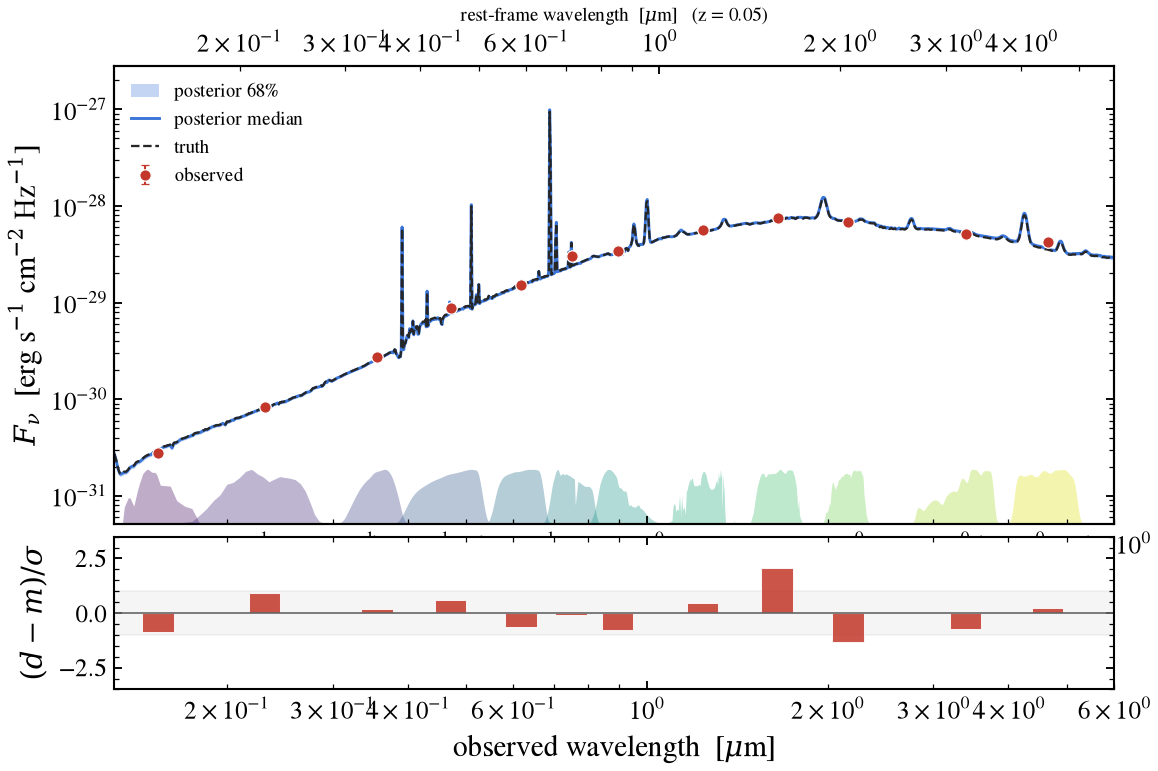

In [8]:
WAVE_OBS = np.geomspace(1300.0, 6e4, 1200)  # 0.13–6 μm covers GALEX → WISE W2
z_truth = float(truth_full["redshift"])
dl_cm = cosmology.luminosity_distance(z_truth)


def obs_fnu(params):
    pred = sed_model.predict(params)
    lnu_interp = np.interp(
        WAVE_OBS / (1.0 + z_truth), np.asarray(sed_model.wavelengths), np.asarray(pred.rest_sed())
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu_interp), dl_cm, z_truth))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(40)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth_full)

# Posterior photometry via ``predict_photometry`` — the same WavePrecomp LUT
# path the fit used. It serves the filter fluxes straight from the SSP × filter
# table without materializing the full-resolution SED cube, so the posterior
# draws map cheaply (no vmap chunking needed).
phot_draws = np.stack([np.asarray(sed_model.predict_photometry(p)) for p in draw_dicts(N_DRAWS)])
phot_med = np.median(phot_draws, axis=0)

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

wave_um = WAVE_OBS / 1e4

# Filter transmission curves shaded behind the spectrum — Bagpipes/Prospector
# style. Use the matplotlib default qualitative palette across bands.
band_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(phot.filter_waves)))
ymin, ymax = 0.3 * spec_truth.min(), 3 * spec_truth.max()
for fw, ft, color in zip(phot.filter_waves, phot.filter_trans, band_palette):
    fw_um = np.asarray(fw) / 1e4
    ft_norm = np.asarray(ft) / np.max(ft)
    # Map transmission to the bottom 12 % of the log-y axis.
    band = ymin * (ymax / ymin) ** (0.12 * ft_norm)
    ax.fill_between(fw_um, ymin, band, color=color, alpha=0.35, lw=0)

ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.4, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.1, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5.5,
    capsize=2,
    elinewidth=1.0,
    mec="white",
    mew=0.6,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(wave_um.min(), wave_um.max())
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)

# Rest-frame wavelength axis on top.
ax_rest = ax.twiny()
ax_rest.set_xscale("log")
ax_rest.set_xlim(wave_um.min() / (1.0 + z_truth), wave_um.max() / (1.0 + z_truth))
ax_rest.set_xlabel(rf"rest-frame wavelength  [$\mu$m]   (z = {z_truth:.2f})", fontsize=9)

resid = (flux_obs - phot_med) / noise
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(
    wave_eff_um,
    resid,
    width=wave_eff_um * 0.12,
    color=C_DATA,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax_res.set_xscale("log")
ax_res.set_xlim(wave_um.min(), wave_um.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "00_posterior_sed.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "00_posterior_sed.pdf", bbox_inches="tight")

## Star-formation history

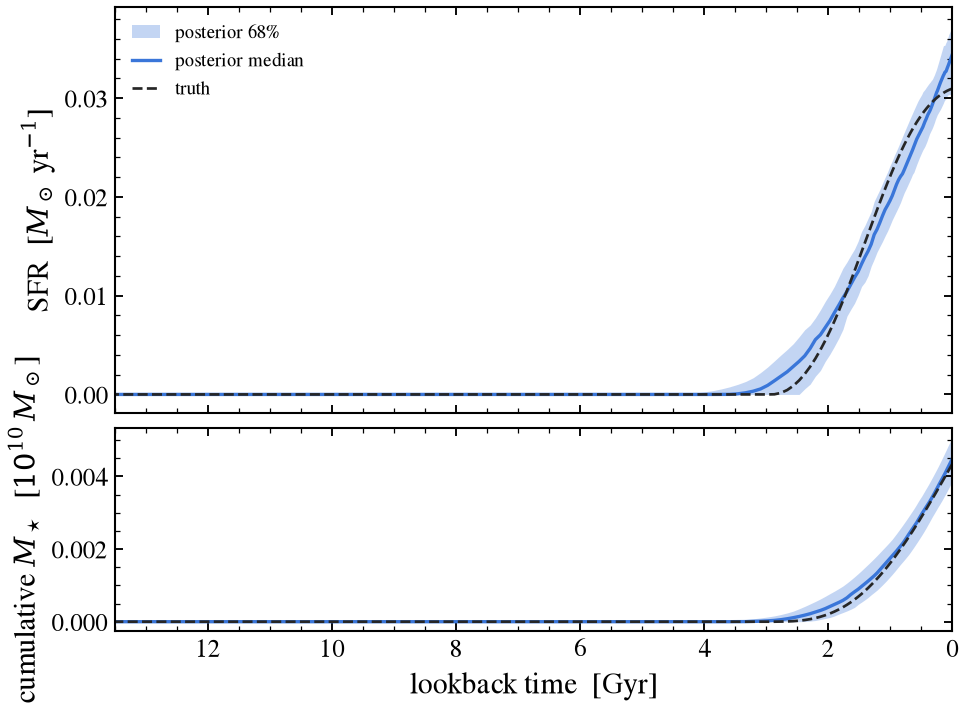

In [9]:
def sfh(p):
    s = sed_model.predict_state(p)
    return (
        np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
        np.asarray(s.derived["sfr_history"]),
    )


sfr_draws, lbt = [], None
for p in draw_dicts(80):
    lbt_i, sfr_i = sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
lbt_t, sfr_t = sfh(truth_full)

# Two-panel SFH: SFR(t) on top, cumulative formed mass on bottom.
fig_sfh, (ax_sfh, ax_cum) = plt.subplots(
    2, 1, figsize=(7.2, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.05)
)

ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_sfh.plot(lbt, sfr_med, color=C_POST, lw=1.6, label="posterior median")
ax_sfh.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.3, label="truth")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_sfh.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax_sfh.get_xticklabels(), visible=False)

# Cumulative formed stellar mass — integrate SFR(t) backwards from now.
dt_yr = np.gradient(lbt * 1e9)  # Gyr → yr, signed
cum_draws = np.flip(np.cumsum(np.flip(sfr_draws * dt_yr[None, :], axis=1), axis=1), axis=1)
cum_lo, cum_med, cum_hi = np.percentile(cum_draws, [16, 50, 84], axis=0)
cum_truth = np.flip(np.cumsum(np.flip(sfr_t * dt_yr), axis=0), axis=0)
ax_cum.fill_between(lbt, cum_lo / 1e10, cum_hi / 1e10, color=C_POST, alpha=0.30, lw=0)
ax_cum.plot(lbt, cum_med / 1e10, color=C_POST, lw=1.6)
ax_cum.plot(lbt_t, cum_truth / 1e10, color=C_TRUTH, ls="--", lw=1.3)
ax_cum.set_ylabel(r"cumulative $M_\star$  [$10^{10}\,M_\odot$]")

for axx in (ax_sfh, ax_cum):
    axx.invert_xaxis()
    axx.set_xlim(13.5, 0)
ax_cum.set_xlabel("lookback time  [Gyr]")

fig_sfh.savefig(FIG_DIR / "00_sfh.png", dpi=300, bbox_inches="tight")
fig_sfh.savefig(FIG_DIR / "00_sfh.pdf", bbox_inches="tight")

## Corner

Free parameters plus derived quantities (`stellar_mass`, `sfr_100myr`,
`sfr_10myr`, in log₁₀), truth dashed.

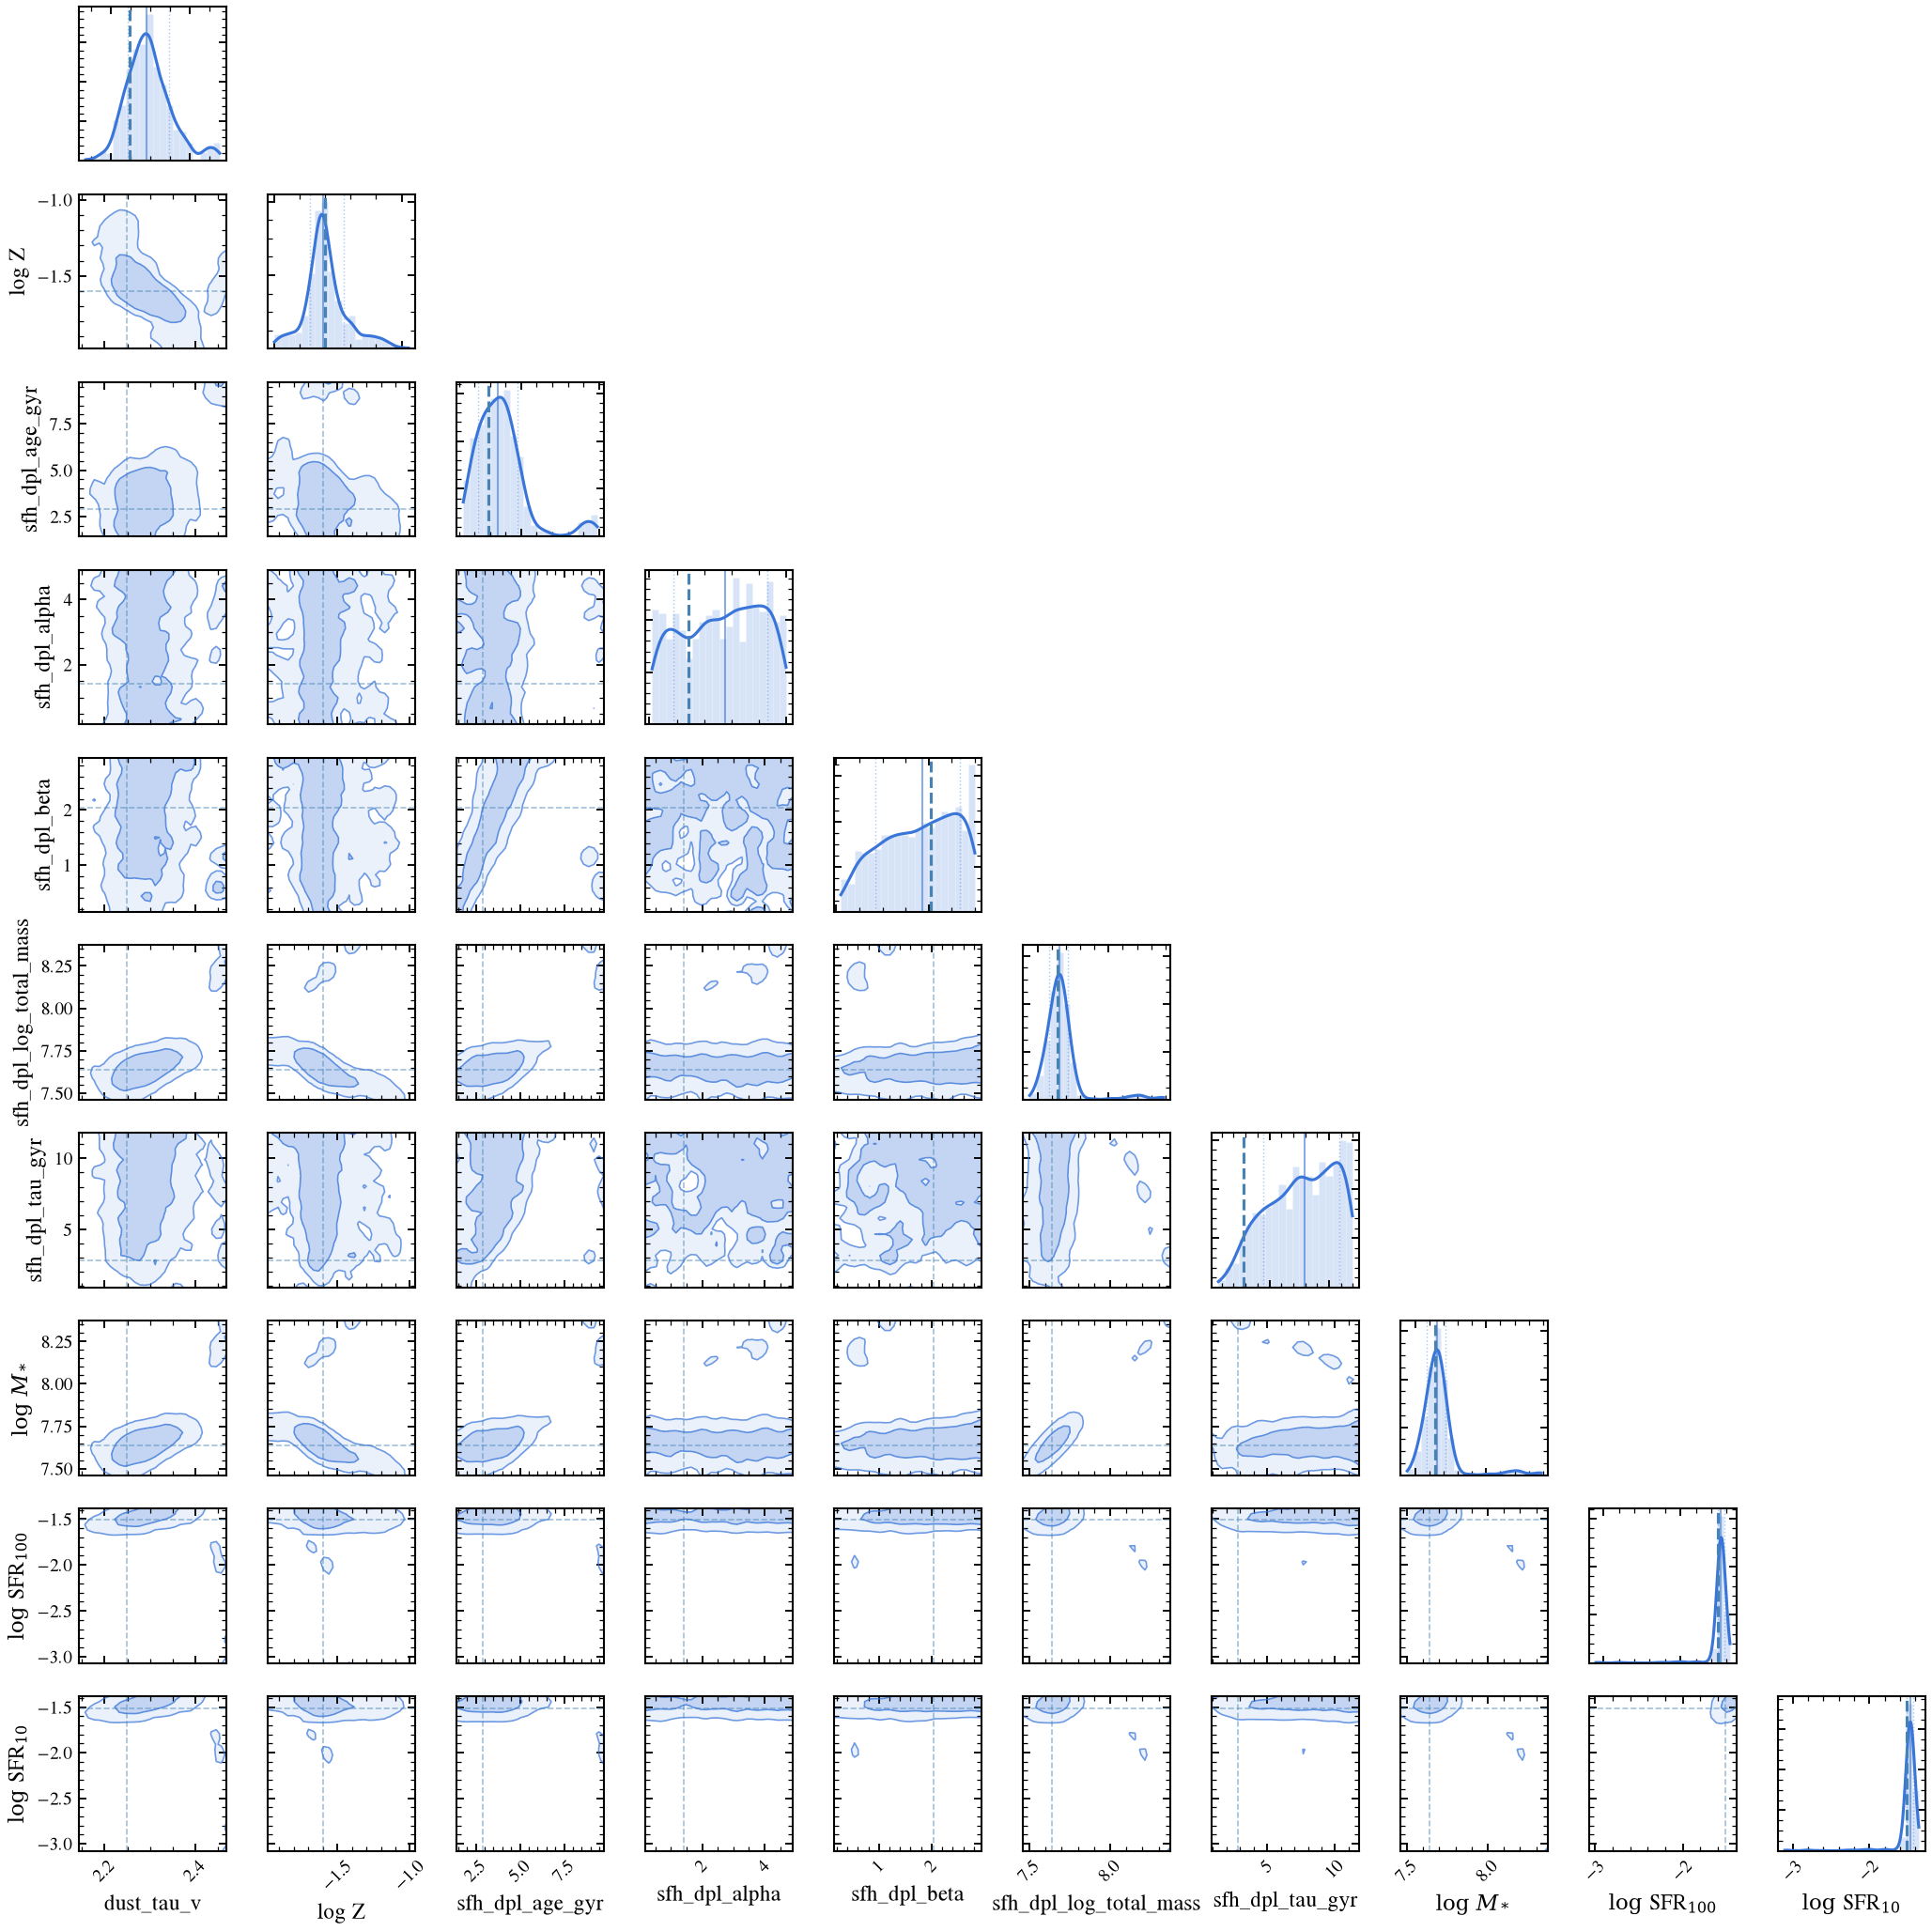

In [10]:
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "00_corner.pdf", bbox_inches="tight")